# GB84 Model Testing Using in-situ measurements from Cabauw, NL

A notebook to perform test runs with the python implementation of the Georgakakos and Bras model from *"A Hydrologically Useful Station Precipitation Model"* (1984)

This Jupyter Notebook tests a precipitation model using validated data from the CESAR network as inputs, with a 10min resolution.

The input data used in this model consist of a combined dataset derived from the **Cesar Network surface data** and **Cloudnet MWR profiles** corresponding to Cabauw.
#### Required Inputs

- **Surface Inputs** (from ERA5 Single Levels):
  - 2-meter air temperature
  - Surface pressure
  - 2-meter dew point temperature



In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from GB84 import calculations_for_convection, rho_m, v,cloud_heights, h_out, phi, f, non_dim_numbers
from scipy import signal
from scipy.stats import pearsonr

c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Table of Contents

1. [Loading the data](#Loading-the-data)
2. [Running the model](#Running-the-model)
3. [Visualizing the outputs](#Visualizing-the-outputs)
4. [Result Analysis](#Result-Analysis)


## Loading the Data


After loading the dataset, only the data corresponding to the **desired time interval** are selected for further analysis.


In [2]:
#choose time period of runs
slice_str = "2024-07-01 00:00:00, 2024-07-03 23:59:00"
slice_tuple = tuple(slice_str.split(", "))

#### CESAR surface measurements 

In [3]:
ground_measurements = xr.open_mfdataset(r'..\data\Cabauw_cesar_surface\cesar_surface_meteo_lc1_t10_v1.0_202407.nc')
var = ['TA002','P0','TD002','RH002']
measurements = ground_measurements[var]
measurements = measurements.dropna(dim='time',how='any')

measurements_used = measurements.sel(time=slice(*slice_tuple))

In [4]:
time = measurements_used.sel(time=slice(*slice_tuple)).time
dt_seconds = np.diff(time).astype('timedelta64[s]').astype(float)

#### Radiometer LWP 

The liquid water path as measured from the MWR in Cabauw, to be used as the initial state

In [5]:
radiometer = xr.open_mfdataset(r'..\data\Cabaw_radiometer\*.nc')
radiometer_lwp = radiometer['lwp'].sel(time=time,method='nearest')

Storing the time values and the timestep.

In [6]:
#inputs

#temperature on the ground
T_surf = measurements_used['TA002'].values #[K]


#pressure
p_surf = measurements_used['P0'].values*100  #[Pa]

#dew point temperature
T_d_arr = measurements_used['TD002'].values     #[K]

#state
X = np.zeros(len(T_surf))
X[0] = radiometer_lwp[0]   #initial state in kg/m2 taken from radiometer LWP

#### Parsivel rainfall data

Reading and storing the Parsivel 1 rainfall measurements from Cabauw, which are to be used for the assessment of the model's performance and/or as inputs to the Kalman filter.

In [7]:
parsivel_1 = xr.open_dataset(r'..\data\Cabaw_parsivel\PAR001_Cabauw_202407.nc')
reference_date = np.datetime64("1970-01-01")

# Convert minutes into datetime
datetime_values = reference_date + parsivel_1.epoch_time.astype("timedelta64[s]")
parsivel_1['time'] = datetime_values


rain_rate = parsivel_1.rainfall_rate_32bit.sel(time=time,method='nearest')
hourly_avg = rain_rate.resample(time='1H').mean()

c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\xarray\groupers.py:490: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(


### Testing the model

#### Initializing Model Output Arrays

Empty arrays are created to store the outputs of the model. These arrays are initialized with dimensions `(time)`.


In [8]:
P = np.zeros(len(T_surf))
P_0 = np.zeros(len(T_surf))
f_arr = np.zeros(len(T_surf))
h_arr = np.zeros(len(T_surf))

#### Model running loop

Loop for the thermodynamical calculations at each timestep and then for the calculation of precipitation rates and state propagation in time

In [9]:
#loop for finding the precipitation given the T_0 and p

for i in range(0,len(T_surf)):
    #inputs
    T_0 = T_surf[i]
    p_0 = p_surf[i]
    T_d = T_d_arr[i]

    #thermodynamics and in cloud calculations
    p_s,T_s,p_t, T_m, T_t,T_s_up, p_s_up = calculations_for_convection(T_0, T_d, p_0, obs=False).run()
    Z_c,Z_b = cloud_heights(T_s,T_t,T_0,p_s,p_t,p_0)

    #fluxes
    rho = rho_m(T_s,T_t,p_s,p_t)
    v_updr = v(T_m,T_s_up)
    O_b,O_t,h_v = h_out(v_updr,Z_c).run()   #outflows and sources of water

    #precipitation
    P[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*X[i]

    #state update
    if i<(len(T_surf)-1):
        X[i+1] = X[i] + dt_seconds[i]*(f(T_d,p_0,p_t,T_t,rho,v_updr) - h_out(v_updr,Z_c).run()[2]*X[i])


### Plots and results

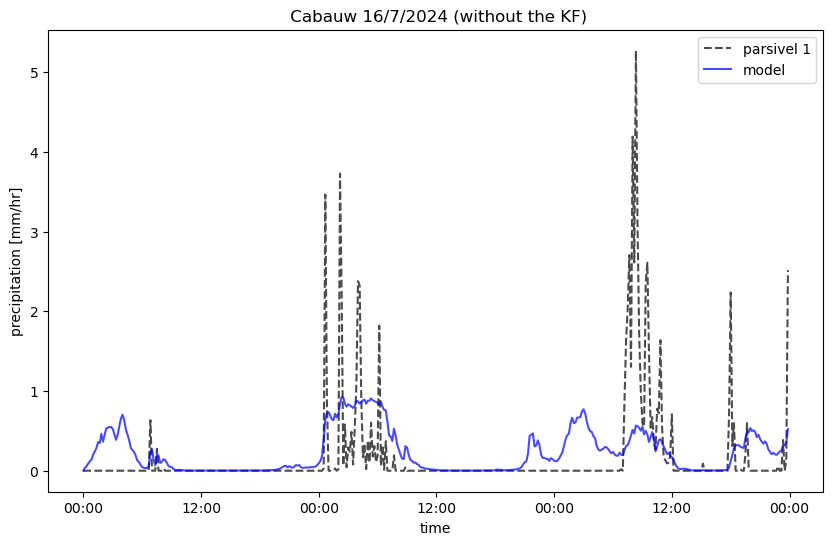

In [10]:
plt.figure(figsize=(10,6))
t_step = np.linspace(0,len(P),len(P))
import matplotlib.dates as mdates

#plt.plot(t_step,P_0*3600,label='model (steady state)')
plt.plot(time,rain_rate,label='parsivel 1',color='black',alpha=0.7,linestyle='--') 
plt.plot(time,P*3600,label='model',color='blue',alpha=0.7)   #P [kg/m2/s] = P/1000kg/m3 = P/1000 m/s = P* 3600 [mm/hr]
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xlabel('time')
plt.title(' Cabauw 16/7/2024 (without the KF)')
plt.ylabel('precipitation [mm/hr]')
plt.legend()
#plt.grid()
plt.show()
